In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("loan_data.csv")
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


## handling missing  values

In [3]:
categorical_cols=data.select_dtypes(include=["object"]).columns
numerical_cols=data.select_dtypes(include=["float64"]).columns

In [4]:
from sklearn.impute import SimpleImputer
num_imputer=SimpleImputer(strategy="mean")
data[numerical_cols]= num_imputer.fit_transform(data[numerical_cols])
cate_imputer=SimpleImputer(strategy="most_frequent")
data[categorical_cols]= cate_imputer.fit_transform(data[categorical_cols])

In [5]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [6]:
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### EDA

In [7]:
classes_count=data["Loan_Approved"].value_counts()
classes_count
classes_count.index

Index(['No', 'Yes'], dtype='object', name='Loan_Approved')

([<matplotlib.patches.Wedge at 0x21317bb0c50>,
 [Text(-0.6521425375337495, 0.8858386482531919, 'No'),
  Text(0.6521428261765839, -0.8858384357581341, 'Yes')],
 [Text(-0.3557141113820451, 0.48318471722901374, '70.2%'),
  Text(0.3557142688235912, -0.4831846013226186, '29.8%')])

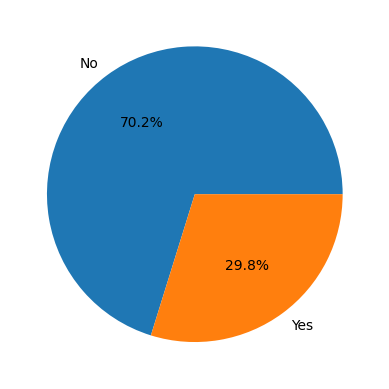

In [8]:
plt.pie(classes_count,labels=classes_count.index, autopct="%1.1f%%")

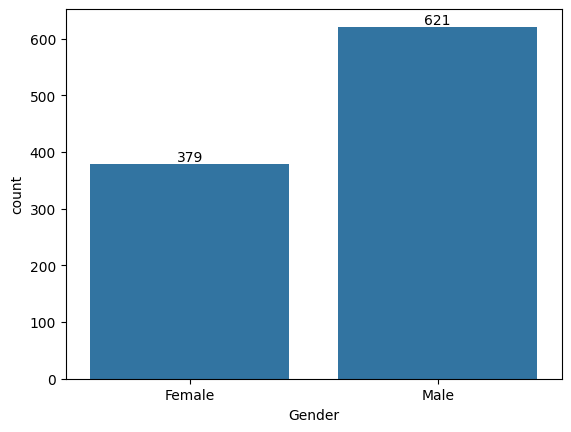

In [9]:
ax = sns.countplot(data=data, x="Gender")

for container in ax.containers:
    ax.bar_label(container)

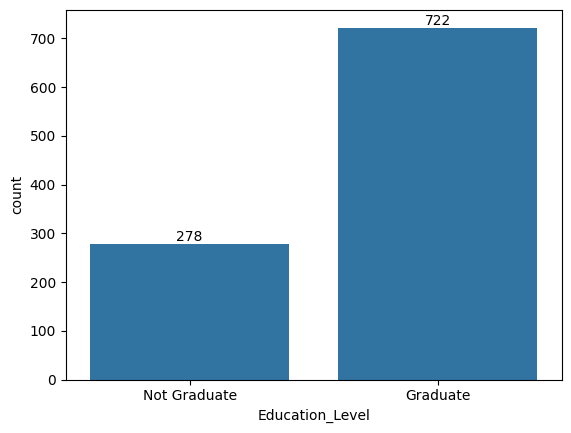

In [10]:
ax = sns.countplot(data=data, x="Education_Level")

for container in ax.containers:
    ax.bar_label(container)

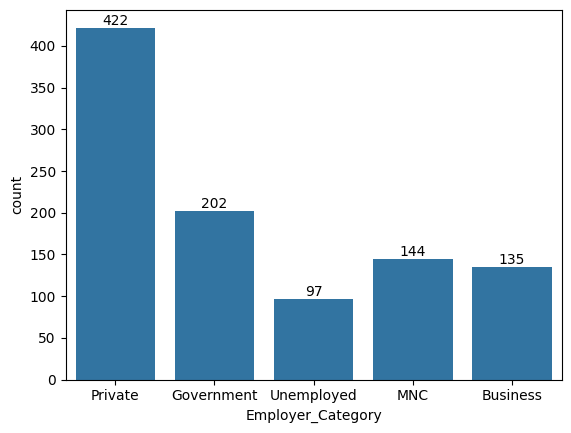

In [11]:
ax = sns.countplot(data=data, x="Employer_Category")

for container in ax.containers:
    ax.bar_label(container)

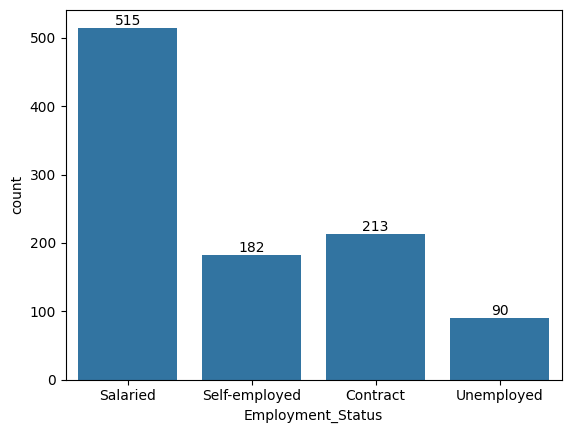

In [12]:
ax = sns.countplot(data=data, x="Employment_Status")

for container in ax.containers:
    ax.bar_label(container)

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

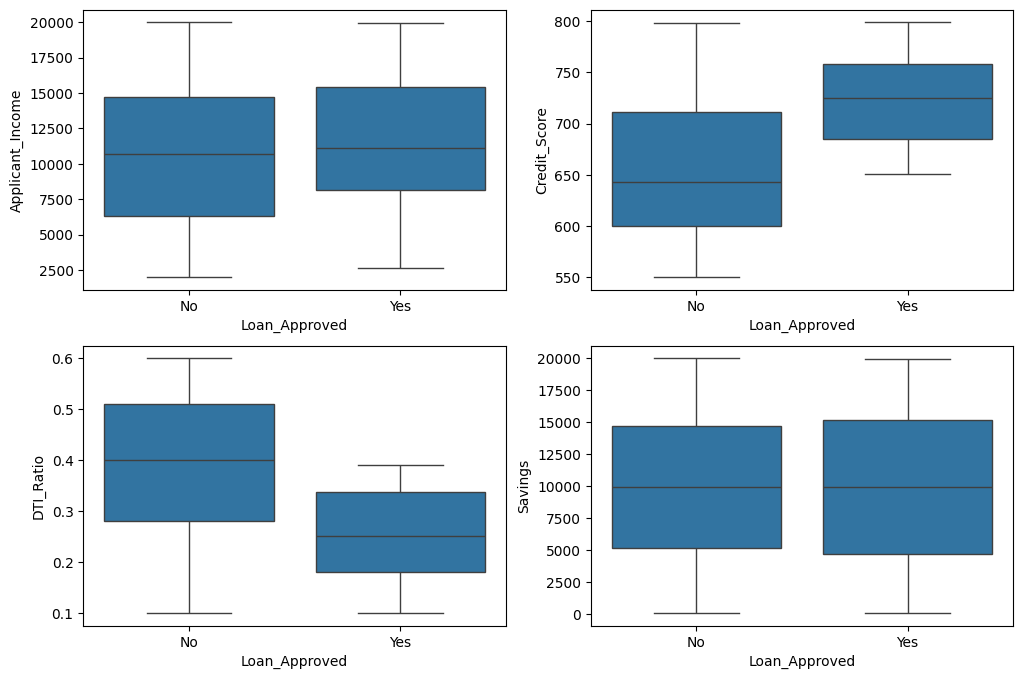

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(ax=axes[0, 0], data=data, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=data, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data=data, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=data, x="Loan_Approved", y="Savings")

## encoding

In [14]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [15]:
ordinal_cols=["Employment_Status","Marital_Status","Loan_Approved"]
nominal_cols=["Loan_Purpose","Property_Area","Education_Level","Employer_Category","Gender"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(data[nominal_cols])
encoded_df=pd.DataFrame(encoded ,columns=ohe.get_feature_names_out(nominal_cols), index=data.index)

In [16]:
encoded_df.head()

,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [17]:
data=pd.concat([data.drop(columns=nominal_cols),encoded_df],axis=1)

In [18]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [19]:
ordinal_cols=["Employment_Status","Marital_Status","Loan_Approved"]
labelEn=LabelEncoder()
for col in ordinal_cols:
    data[col] = labelEn.fit_transform(data[col])

In [20]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
0,1.0,17795.0,1387.0,1,51.0,0,0.0,637.0,4.0,0.53,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2860.0,2679.0,1,46.0,0,3.0,621.0,2.0,0.30,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,3.0,7390.0,2106.0,1,25.0,1,2.0,674.0,4.0,0.20,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,1,40.0,0,2.0,579.0,3.0,0.31,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,2,31.0,1,2.0,721.0,1.0,0.29,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [21]:
nums_col=data.select_dtypes(include="number")
corr_matrix=nums_col.corr()
corr_matrix

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
Applicant_ID,1.000000,0.020970,0.041140,0.026294,0.014579,-0.010343,0.012495,-0.028170,0.024995,0.000174,...,-0.039878,0.019178,0.012969,-0.030187,0.004906,0.005906,-0.074056,0.022803,0.038417,0.036067
Applicant_Income,0.020970,1.000000,0.007545,0.005975,-0.023988,0.010057,-0.026658,-0.009818,-0.010457,-0.009107,...,0.074209,-0.031234,0.004845,-0.036260,-0.014593,-0.025011,0.102589,-0.044639,-0.011995,-0.020871
Coapplicant_Income,0.041140,0.007545,1.000000,0.005859,0.014306,-0.011431,-0.026733,0.058423,0.012418,0.058078,...,0.016022,0.059549,-0.010058,0.030045,-0.022918,-0.001146,0.037640,0.004312,-0.047929,-0.010148
Employment_Status,0.026294,0.005975,0.005859,1.000000,-0.020578,-0.019976,0.051529,-0.050434,0.023561,0.001288,...,0.008010,0.007568,-0.042253,0.011611,-0.048035,0.008444,0.021774,-0.004442,-0.029418,0.001134
Age,0.014579,-0.023988,0.014306,-0.020578,1.000000,0.009162,-0.018767,-0.004212,0.023330,0.007903,...,0.029865,0.037293,0.003100,-0.025661,0.025020,-0.066041,0.021232,-0.012960,0.072462,0.048402
Marital_Status,-0.010343,0.010057,-0.011431,-0.019976,0.009162,1.000000,-0.011410,0.056176,0.018010,-0.014850,...,-0.004416,-0.063001,0.056121,-0.065028,0.008171,-0.010990,0.015409,-0.019668,0.023773,0.018513
Dependents,0.012495,-0.026658,-0.026733,0.051529,-0.018767,-0.011410,1.000000,-0.007687,-0.026338,0.011498,...,0.027343,-0.005785,-0.032278,0.024082,-0.023493,-0.009250,-0.018757,0.030197,-0.054147,0.013706
Credit_Score,-0.028170,-0.009818,0.058423,-0.050434,-0.004212,0.056176,-0.007687,1.000000,-0.007130,0.002338,...,-0.008658,0.015324,-0.006946,0.004445,0.005367,-0.007076,0.066736,-0.000049,-0.046087,-0.039739
Existing_Loans,0.024995,-0.010457,0.012418,0.023561,0.023330,0.018010,-0.026338,-0.007130,1.000000,0.047008,...,0.001777,0.023212,-0.053971,0.035629,-0.008208,-0.009642,0.030520,-0.019306,0.045391,-0.038762
DTI_Ratio,0.000174,-0.009107,0.058078,0.001288,0.007903,-0.014850,0.011498,0.002338,0.047008,1.000000,...,-0.014125,-0.036648,0.044898,-0.006156,0.010084,-0.007214,0.002090,-0.003506,0.026018,0.009624


In [22]:
nums_col.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                   1.000000
Credit_Score                    0.451175
Applicant_Income                0.119796
Employer_Category_MNC           0.069049
Loan_Purpose_Personal           0.034043
Marital_Status                  0.030182
Property_Area_Urban             0.025963
Collateral_Value                0.021868
Coapplicant_Income              0.004230
Loan_Purpose_Home               0.002118
Employer_Category_Private      -0.003347
Applicant_ID                   -0.011167
Property_Area_Semiurban        -0.012967
Savings                        -0.013437
Loan_Purpose_Education         -0.016684
Employer_Category_Unemployed   -0.021468
Age                            -0.022343
Dependents                     -0.023811
Existing_Loans                 -0.034794
Employer_Category_Government   -0.039187
Education_Level_Not Graduate   -0.052920
Gender_Male                    -0.054342
Loan_Purpose_Car               -0.056416
Employment_Status              -0.069986
Loan_Term       

## heatmap

<Axes: >

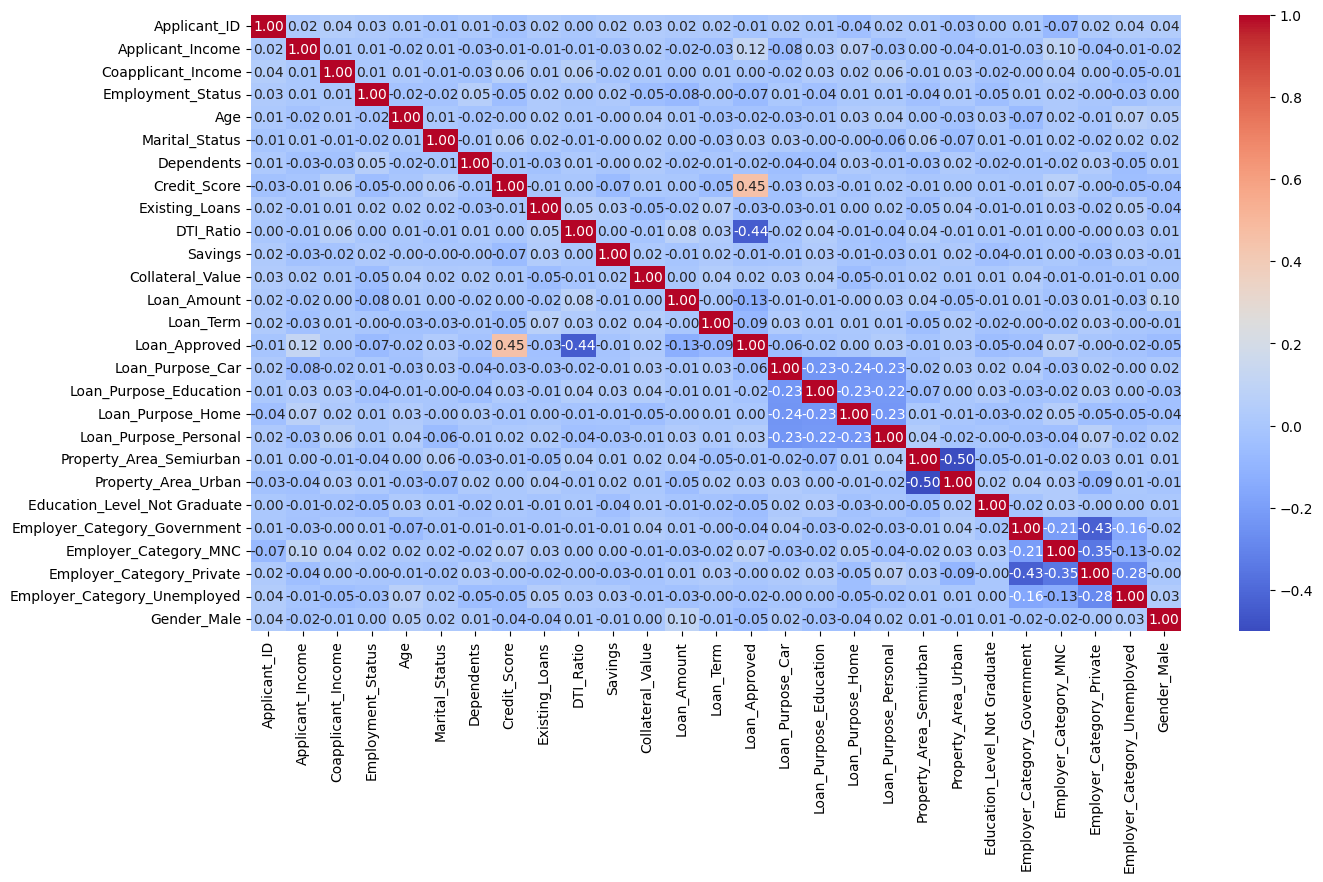

In [25]:
plt.figure(figsize=(15,8)) 
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm")

## train test splt

In [29]:
x=data.drop(columns=["Loan_Approved"])
y=data["Loan_Approved"]

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [47]:
x_train_scaled

array([[-1.66336551, -1.01234556,  1.02716377, ..., -0.85972695,
        -0.30723158, -1.29444401],
       [ 0.1281584 , -1.23639141, -1.59187898, ..., -0.85972695,
        -0.30723158,  0.77253245],
       [ 0.69464817, -0.01158625,  1.33606578, ...,  1.16316   ,
        -0.30723158,  0.77253245],
       ...,
       [ 1.27884075, -0.22727759,  0.35008962, ...,  1.16316   ,
        -0.30723158,  0.77253245],
       [ 0.00501768,  1.12970221, -0.46470044, ..., -0.85972695,
        -0.30723158,  0.77253245],
       [-1.40490455, -1.75526629,  0.01434173, ..., -0.85972695,
        -0.30723158,  0.77253245]], shape=(800, 26))

In [48]:
x_test_scaled

array([[ 0.07859054,  0.42610546,  0.55091079, ...,  1.16316   ,
        -0.30723158,  0.77253245],
       [ 0.84335174,  1.00971366,  0.58995935, ...,  1.16316   ,
        -0.30723158,  0.77253245],
       [ 0.85397342, -0.67557096, -0.54558674, ...,  1.16316   ,
        -0.30723158, -1.29444401],
       ...,
       [-1.02960507, -0.67980585, -0.10106072, ...,  1.16316   ,
        -0.30723158, -1.29444401],
       [ 0.40432216, -0.37650705, -0.97825874, ..., -0.85972695,
        -0.30723158,  0.77253245],
       [-1.48987801, -0.73647272, -1.24497436, ...,  1.16316   ,
        -0.30723158,  0.77253245]], shape=(200, 26))

## Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

In [53]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,confusion_matrix

precision=precision_score(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
confusion_mat=confusion_matrix(y_test,y_pred)

print("precision:",precision)
print("accuracy:",accuracy)
print("recall:",recall)
print("f1-score:",f1)
print("confusion_matrix:",confusion_mat)

precision: 0.7833333333333333
accuracy: 0.865
recall: 0.7704918032786885
f1-score: 0.7768595041322314
confusion_matrix: [[126  13]
 [ 14  47]]


## knn

In [58]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=9)
knn_model.fit(x_train_scaled,y_train)
y_pred=knn_model.predict(x_test_scaled)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0])

In [59]:
precision=precision_score(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
confusion_mat=confusion_matrix(y_test,y_pred)

print("precision:",precision)
print("accuracy:",accuracy)
print("recall:",recall)
print("f1-score:",f1)
print("confusion_matrix:",confusion_mat)

precision: 0.6470588235294118
accuracy: 0.745
recall: 0.36065573770491804
f1-score: 0.4631578947368421
confusion_matrix: [[127  12]
 [ 39  22]]


## naive baye's

In [60]:
from sklearn.naive_bayes import GaussianNB

nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0])

In [61]:
precision=precision_score(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
confusion_mat=confusion_matrix(y_test,y_pred)

print("precision:",precision)
print("accuracy:",accuracy)
print("recall:",recall)
print("f1-score:",f1)
print("confusion_matrix:",confusion_mat)

precision: 0.5833333333333334
accuracy: 0.745
recall: 0.5737704918032787
f1-score: 0.5785123966942148
confusion_matrix: [[114  25]
 [ 26  35]]


## best model=> Logistic Regresssion

## feature engineering

In [62]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Add or Transform features
data["DTI_Ratio_sq"] = data["DTI_Ratio"] ** 2
data["Credit_Score_sq"] = data["Credit_Score"] ** 2

data["Applicant_Income_log"] = np.log1p(data["Applicant_Income"]) 

# Features and target
X = data.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio", "Applicant_Income"])
y = data["Loan_Approved"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
y_pred

precision=precision_score(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
confusion_mat=confusion_matrix(y_test,y_pred)

print("precision:",precision)
print("accuracy:",accuracy)
print("recall:",recall)
print("f1-score:",f1)
print("confusion_matrix:",confusion_mat)

precision: 0.7833333333333333
accuracy: 0.865
recall: 0.7704918032786885
f1-score: 0.7768595041322314
confusion_matrix: [[126  13]
 [ 14  47]]
